In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import json
import sys
import os
import scipy.cluster.hierarchy as sch


models_path = os.path.abspath(os.path.join('models'))
sys.path.append(models_path)

src_path = os.path.abspath(os.path.join('src'))
sys.path.append(src_path)

from DKT.dkt_model import DKT
from KTDataset import KTDataset


In [2]:
current_folder = 'notebooks/DKT/relu_embeddings/embed_dim_2'

df_answers = pd.read_csv('data/preprocessed/df_answers.csv')
df_skill_names = pd.read_csv('data/preprocessed/df_skill_names.csv')

# Load the configuration file
with open(os.path.join(current_folder, 'best_dkt_config_relu_2.json'), 'r') as f:
    config = json.load(f)

kt_dataset = KTDataset(df_answers, df_skill_names)
df_embeddings = kt_dataset.df_skill_names[~df_skill_names['skill_name'].isna()].copy()

# Step 3: Instantiate the model
model = DKT(**config['model_params'])

# Step 4: Load the saved parameters
model.load_state_dict(torch.load(os.path.join(current_folder, 'best_dkt_model_relu_2.pth'),
                                 map_location=torch.device('cpu')))
model.eval()  # Set the model to evaluation mode

num_skills = config['model_params']['num_skills']


C:\Users\bokovacs\AppData\Local\Temp\ipykernel_16672\1562582486.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(current_fo

In [4]:
# Create one-hot vectors and obtain embeddings
def get_embedding(skill_id, model, num_skills):
    # Create one-hot vector as a tensor
    one_hot = torch.zeros(num_skills)
    one_hot[skill_id - 1] = 1  # Adjusting index since skill_ids_renumbered starts from 1
    # Get the embedding for the one-hot vector
    embedding = model.embedding(one_hot) # Use skill_id-1 as index for embedding
    return embedding.squeeze(0).detach().numpy()


In [6]:
# Get embeddings for each row and store them as new columns
embeddings = df_embeddings["skill_ids_renumbered"].apply(lambda x: get_embedding(x, model, num_skills))
embedding_dim = embeddings.iloc[0].shape[0]  # Dimension of embedding

# Split embedding values into individual columns
embedding_columns = [f"embed_{i+1}" for i in range(embedding_dim)]
df_embeddings[embedding_columns] = pd.DataFrame(embeddings.tolist(), index=df_embeddings.index)


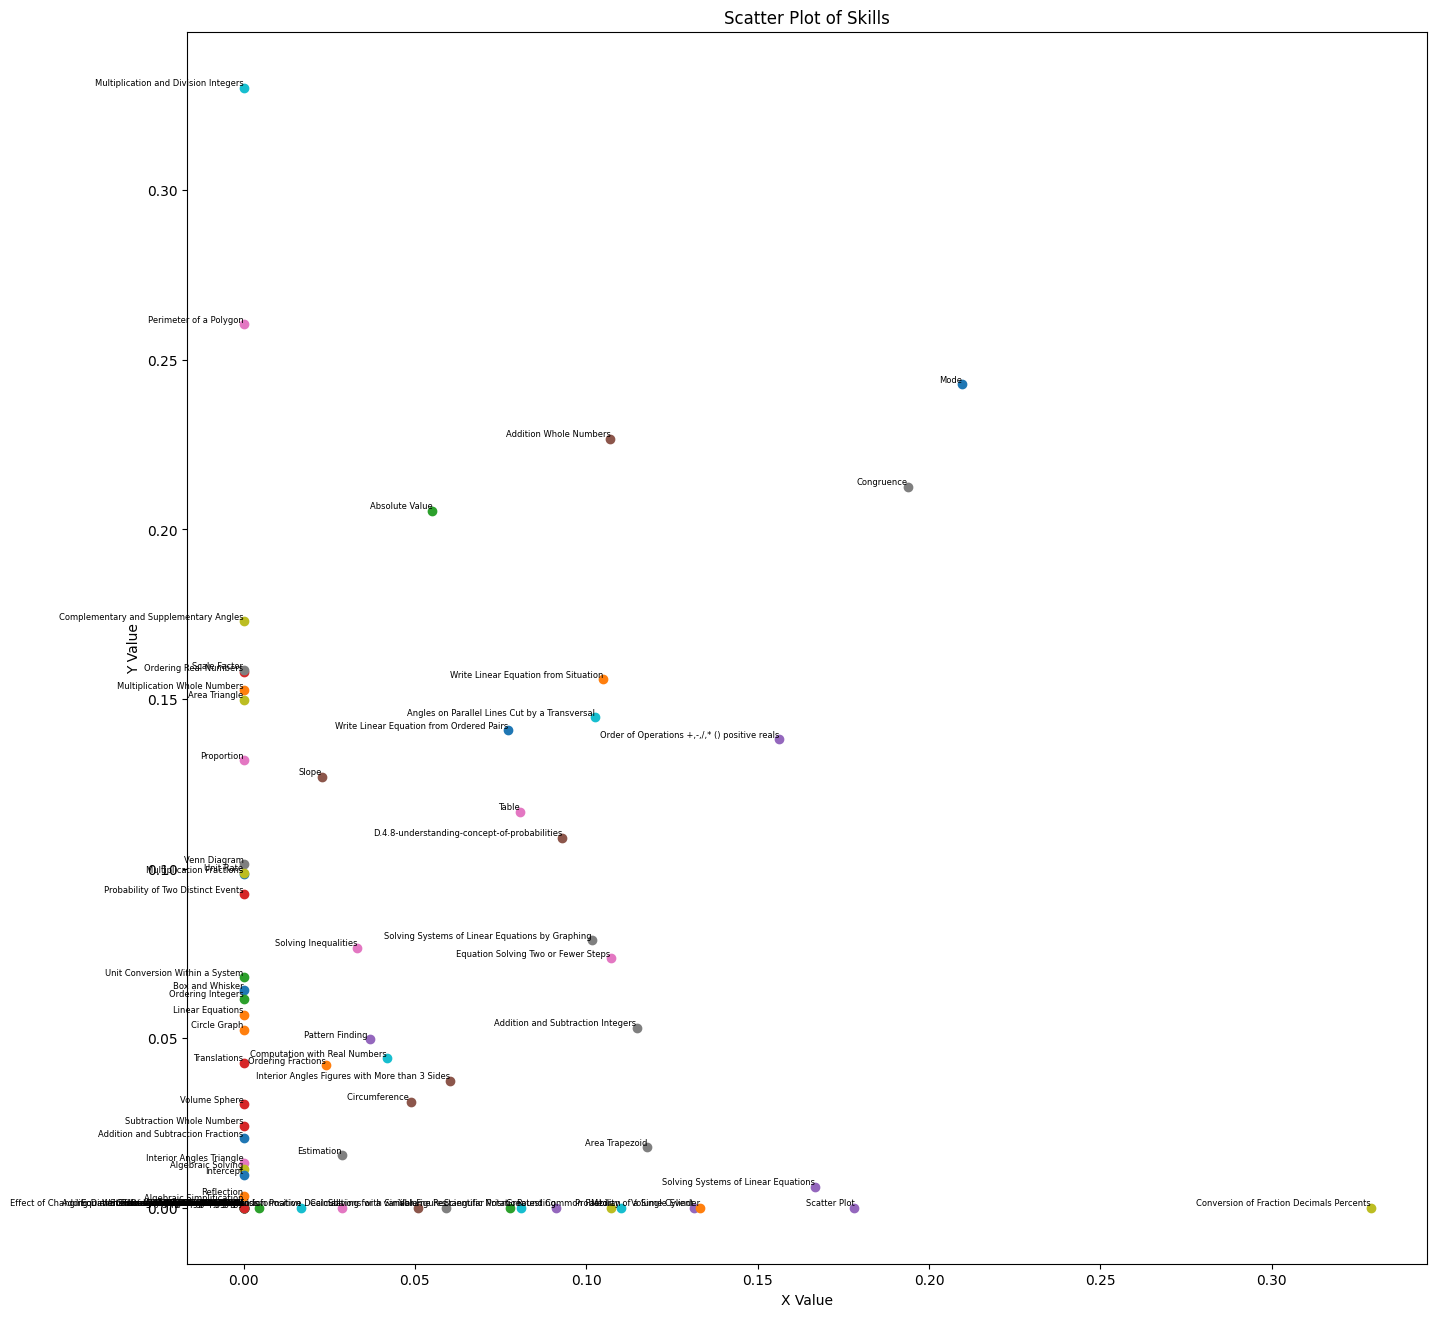

In [8]:
# Create a scatter plot
plt.figure(figsize=(16, 16))

# Plot each scatter point and annotate it with its 'skill_name'
for i, row in df_embeddings.iterrows():
    plt.scatter(row['embed_1'], row['embed_2'])  # You can customize color and marker
    plt.text(row['embed_1'], row['embed_2'], row['skill_name'], fontsize=6, ha='right', va='bottom')

plt.xlabel('X Value')
plt.ylabel('Y Value')
plt.title('Scatter Plot of Skills')
plt.show()


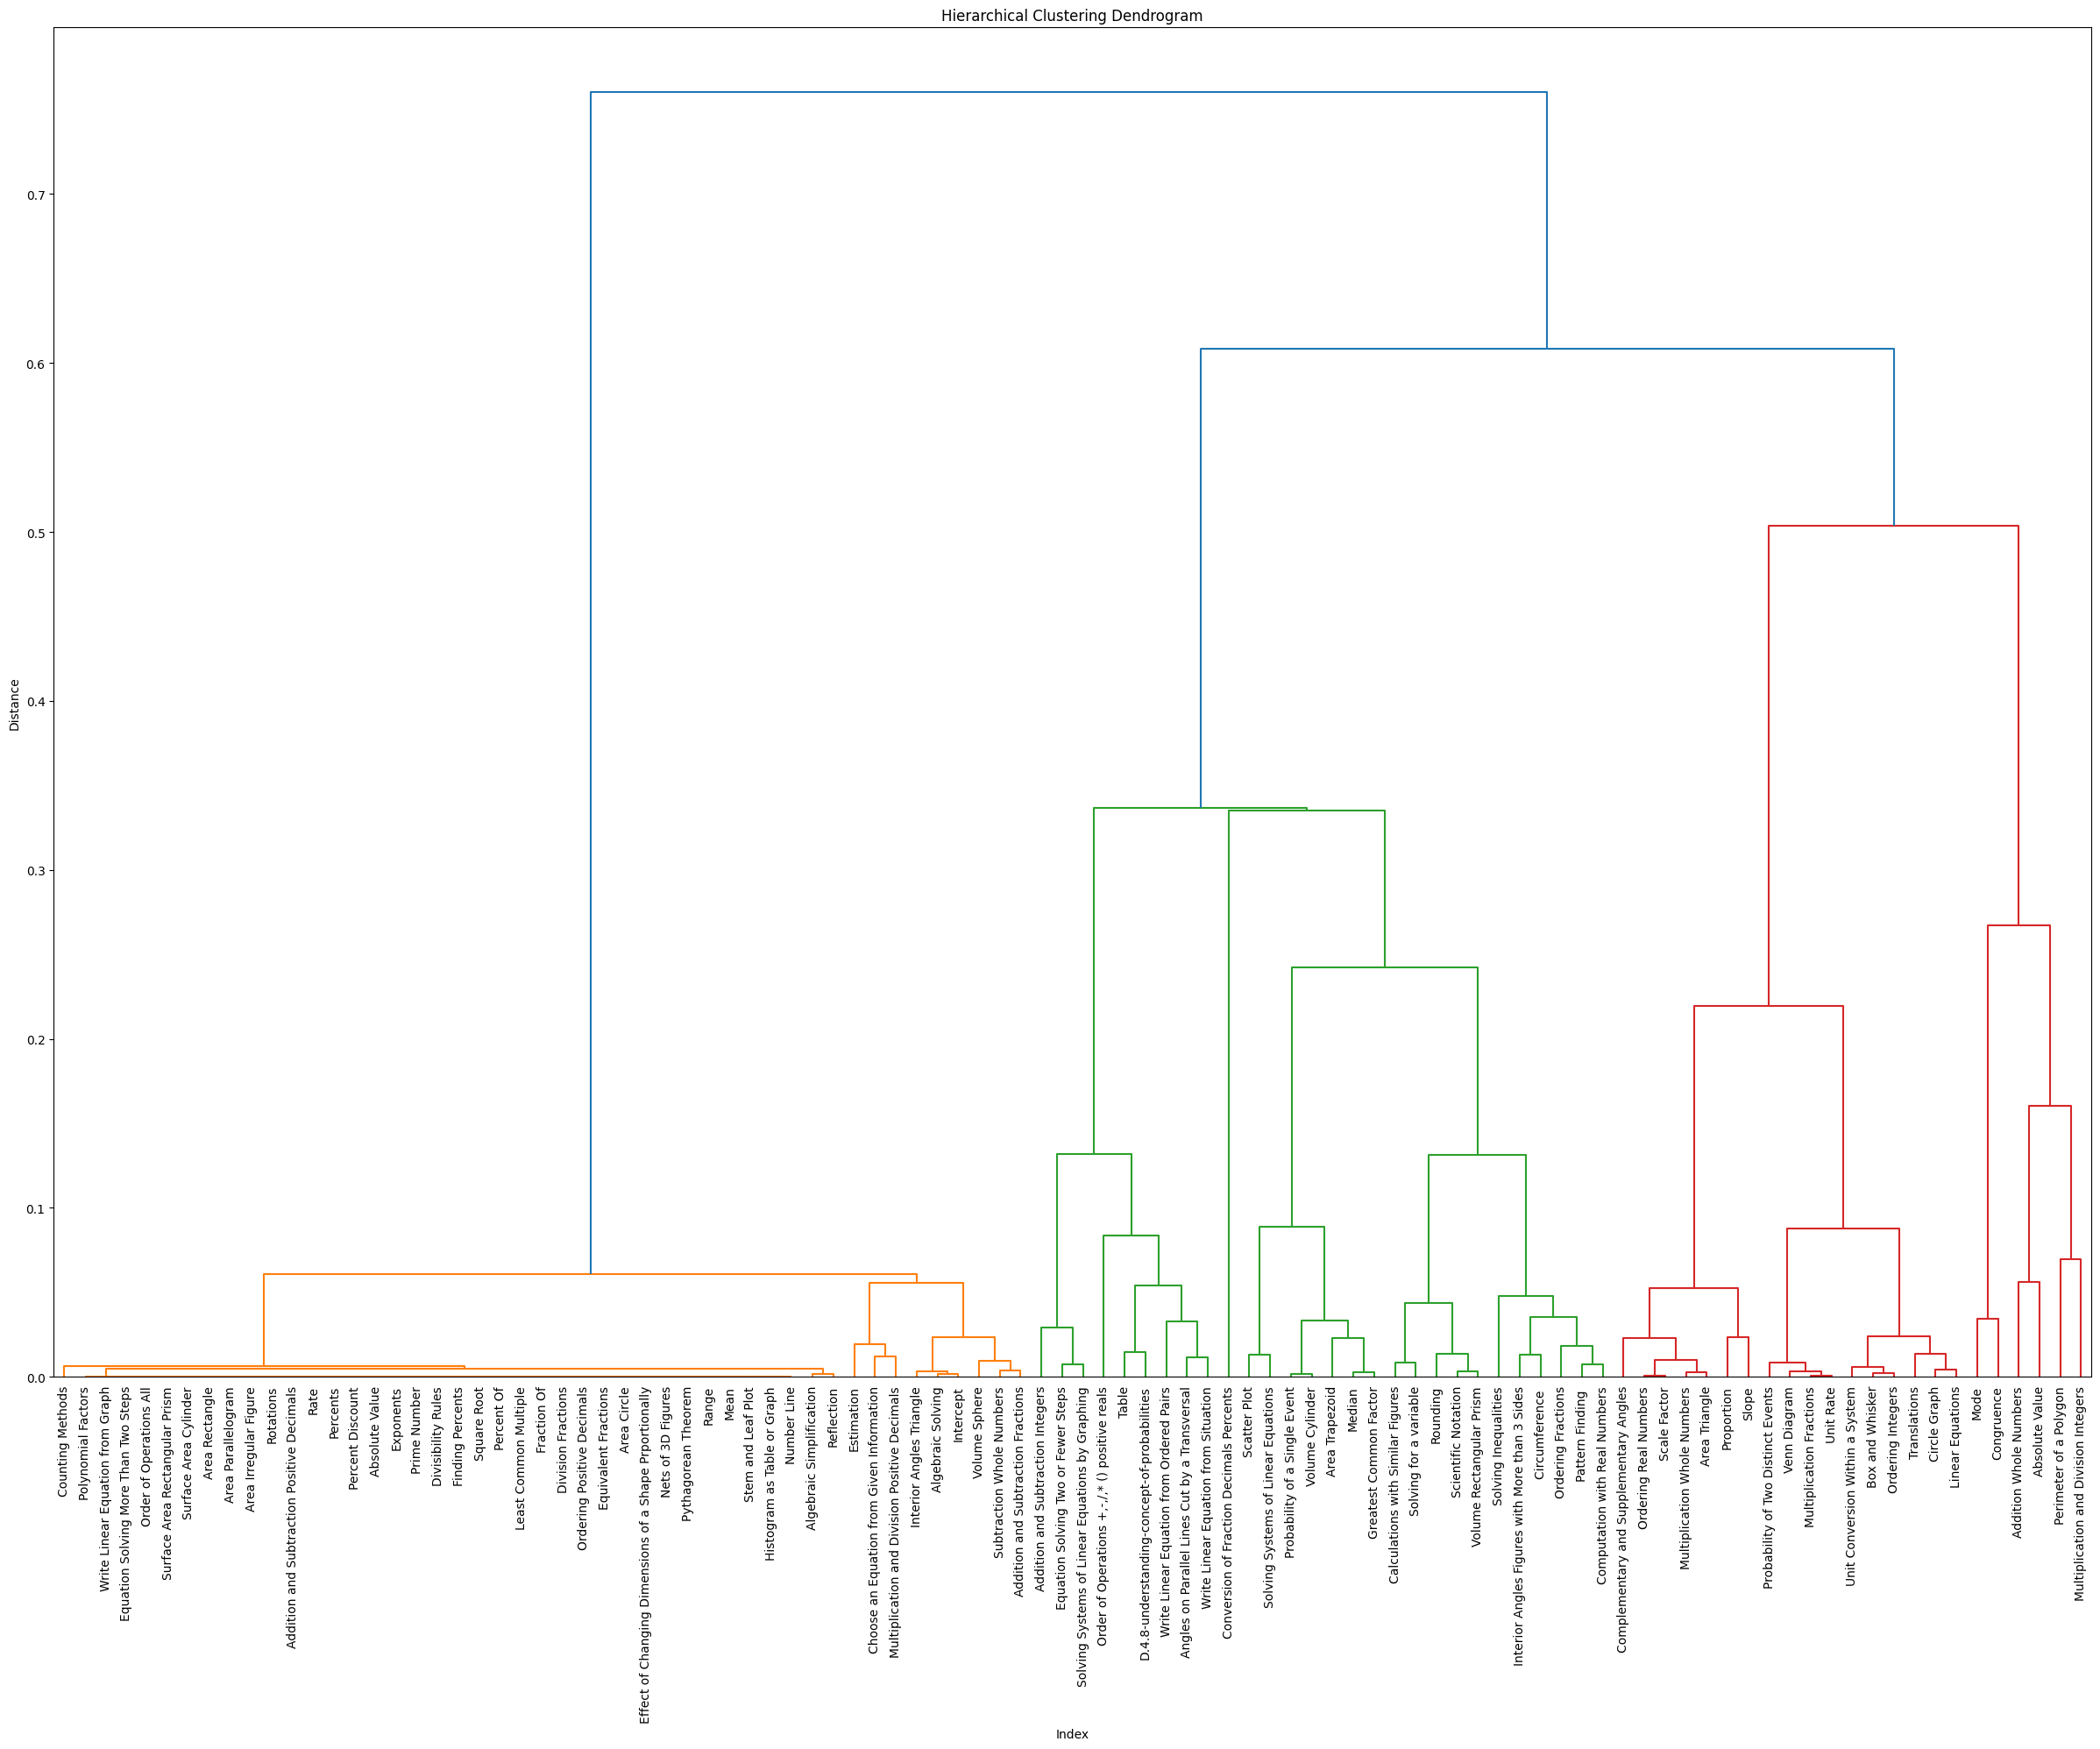

In [9]:
# Calculate the linkage matrix
linkage_matrix = sch.linkage(df_embeddings[['embed_1', 'embed_2']], method='ward')

# Plot the dendrogram
plt.figure(figsize=(30, 20))
sch.dendrogram(linkage_matrix, labels=df_embeddings['skill_name'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()
